In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
store = pd.read_csv("store.csv")

print("Train Shape :", train.shape)
print("Test Shape  :", test.shape)
print("Store Shape :", store.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [ ]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [ ]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [ ]:
df = train.merge(store, on='Store', how='left')

print("Merged Shape:", df.shape)

Merged Shape: (1017209, 18)


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

In [ ]:
df[['Date','Year','Month','Day']].head()

,Date,Year,Month,Day
0,2015-07-31,2015,7,31
1,2015-07-31,2015,7,31
2,2015-07-31,2015,7,31
3,2015-07-31,2015,7,31
4,2015-07-31,2015,7,31


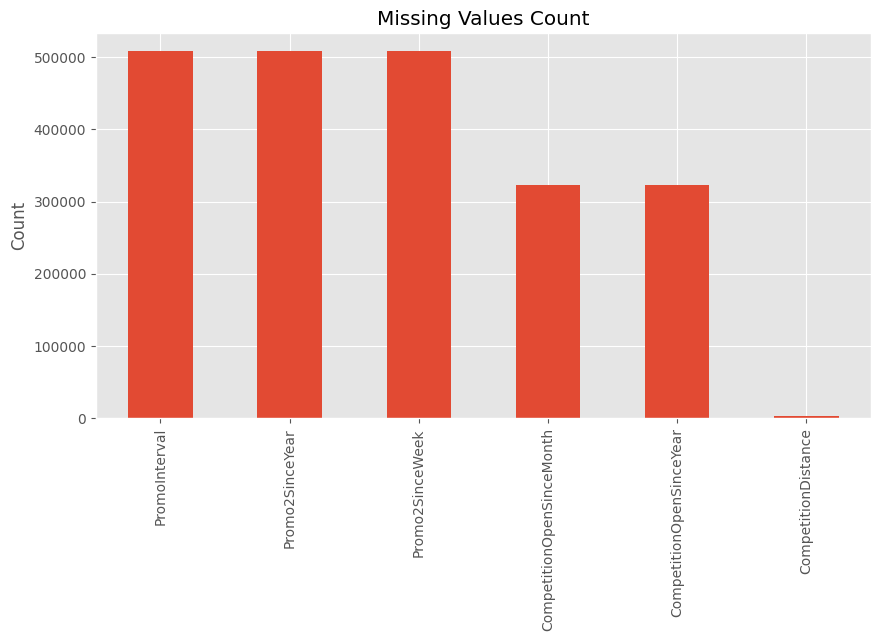

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)

missing = missing[missing > 0]

plt.figure(figsize=(10,5))
missing.plot(kind='bar')

plt.title('Missing Values Count')
plt.ylabel('Count')
plt.show()

In [ ]:
df[['Sales','Customers']].corr()

,Sales,Customers
Sales,1.000000,0.894711
Customers,0.894711,1.000000


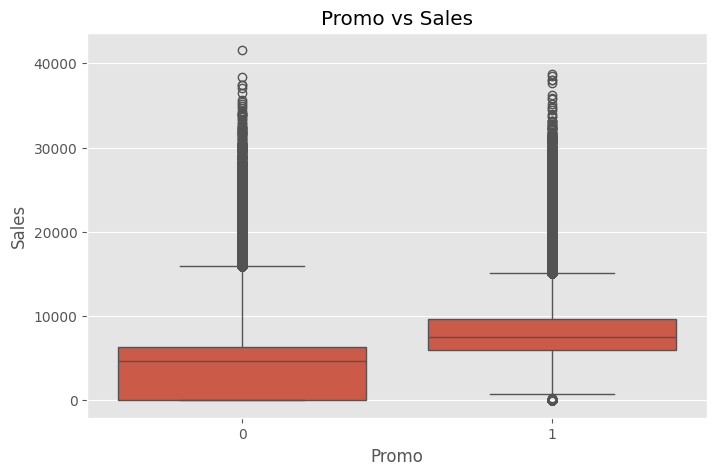

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Promo',
    y='Sales',
    data=df
)

plt.title("Promo vs Sales")
plt.show()

In [ ]:
df.groupby('Promo')['Sales'].mean()

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64

In [ ]:
df.groupby('Assortment')['Sales'].mean().sort_values(ascending=False)

Assortment
b    8553.931999
c    6058.676567
a    5481.026096
Name: Sales, dtype: float64

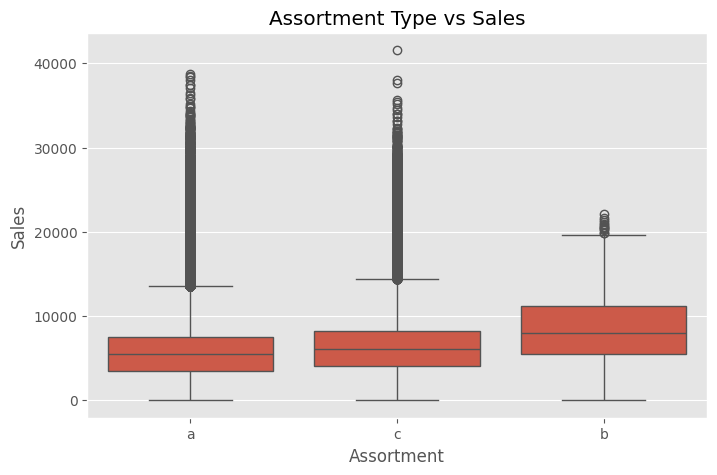

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Assortment',
    y='Sales',
    data=df
)

plt.title('Assortment Type vs Sales')
plt.show()

In [ ]:
df.groupby('StoreType')['Sales'].mean().sort_values(ascending=False)

StoreType
b    10058.837334
a     5738.179710
c     5723.629246
d     5641.819243
Name: Sales, dtype: float64

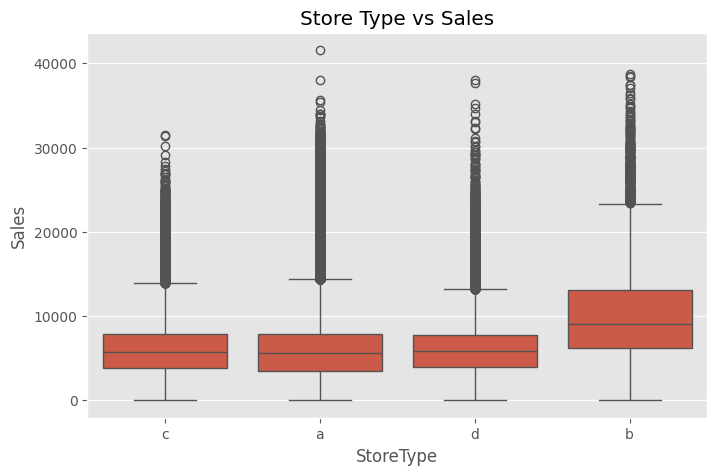

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='StoreType',
    y='Sales',
    data=df
)

plt.title('Store Type vs Sales')
plt.show()

In [ ]:
df[['Sales','CompetitionDistance']].corr()

,Sales,CompetitionDistance
Sales,1.000000,-0.019229
CompetitionDistance,-0.019229,1.000000


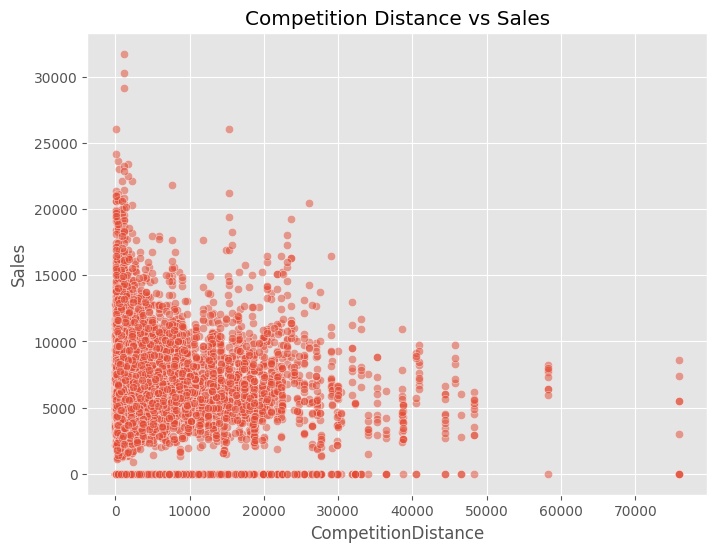

In [ ]:
sample_df = df.sample(10000)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='CompetitionDistance',
    y='Sales',
    data=sample_df,
    alpha=0.5
)

plt.title('Competition Distance vs Sales')
plt.show()

In [ ]:
df.groupby('Promo')['Sales'].mean()

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64

In [ ]:
holiday_sales = df.groupby('StateHoliday')['Sales'].mean()

print(holiday_sales)

StateHoliday
0    5733.530624
0    5980.279717
a     290.735686
b     214.311510
c     168.733171
Name: Sales, dtype: float64


In [ ]:
df.groupby('SchoolHoliday')['Sales'].mean()

SchoolHoliday
0    5620.979034
1    6476.522207
Name: Sales, dtype: float64

In [ ]:
weekend_sales = df.groupby('DayOfWeek')['Sales'].mean()

print(weekend_sales)

DayOfWeek
1    7809.044510
2    7005.244467
3    6555.884138
4    6247.575913
5    6723.274305
6    5847.562599
7     204.183189
Name: Sales, dtype: float64


In [ ]:
monthly_sales = df.groupby('Month')['Sales'].mean()

print(monthly_sales)

Month
1     5465.395529
2     5645.253150
3     5784.578871
4     5738.866916
5     5489.639973
6     5760.964375
7     6064.915711
8     5693.016554
9     5570.246033
10    5537.037419
11    6008.111821
12    6826.611377
Name: Sales, dtype: float64


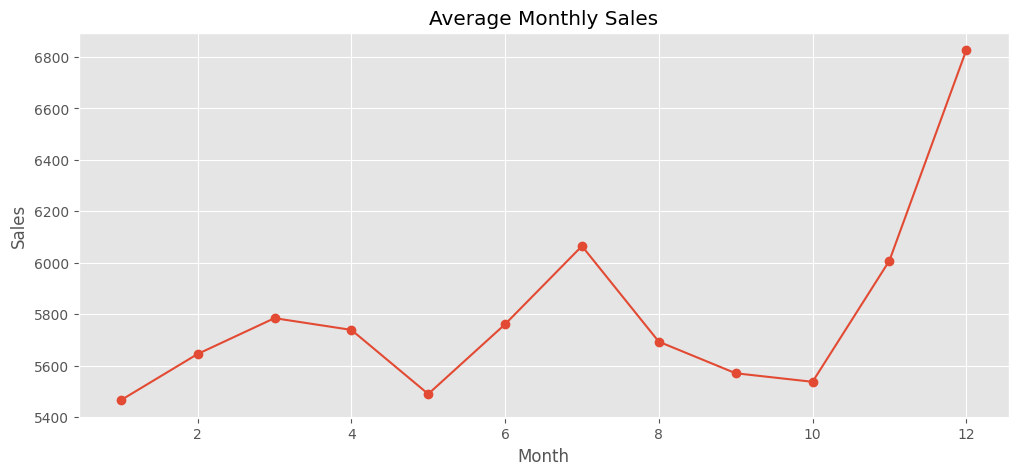

In [ ]:
plt.figure(figsize=(12,5))

monthly_sales.plot(marker='o')

plt.title('Average Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

In [ ]:
df.groupby('Open')['Sales'].mean()

Open
0       0.000000
1    6955.514291
Name: Sales, dtype: float64

In [ ]:
df.groupby('Promo')['Customers'].mean()

Promo
0    517.823542
1    820.098815
Name: Customers, dtype: float64

In [ ]:
df.groupby('StoreType')['Customers'].mean()

StoreType
a     659.034880
b    1987.720846
c     673.265894
d     501.434892
Name: Customers, dtype: float64

In [ ]:
# Date Conversion
df['Date'] = pd.to_datetime(df['Date'])

# Date Features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

# Weekend Feature
df['IsWeekend'] = df['DayOfWeek'].isin([6,7]).astype(int)

# Month Start / End
df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
df['IsMonthEnd'] = df['Date'].dt.is_month_end.astype(int)

df[['Date','Year','Month','Day','WeekOfYear','IsWeekend']].head()

,Date,Year,Month,Day,WeekOfYear,IsWeekend
0,2015-07-31,2015,7,31,31,0
1,2015-07-31,2015,7,31,31,0
2,2015-07-31,2015,7,31,31,0
3,2015-07-31,2015,7,31,31,0
4,2015-07-31,2015,7,31,31,0


In [ ]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day',
       'WeekOfYear', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd'],
      dtype='object')

In [ ]:
df.isnull().sum().sort_values(ascending=False).head(10)

Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
CompetitionDistance            2642
Date                              0
DayOfWeek                         0
Store                             0
SchoolHoliday                     0
dtype: int64

In [ ]:
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(
    df['CompetitionDistance'].median()
)

df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0)

df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)

df['PromoInterval'] = df['PromoInterval'].fillna('None')

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
X = df.drop(['Sales', 'Customers'], axis=1)
y = df['Sales']

In [ ]:
sample_df = df.sample(100000, random_state=42)

X = sample_df.drop(['Sales', 'Customers'], axis=1)
y = sample_df['Sales']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(80000, 23)
(20000, 23)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

TypeError: float() argument must be a string or a real number, not 'Timestamp'

In [ ]:
X.dtypes

Store                                 int64
DayOfWeek                             int64
Date                         datetime64[ns]
Open                                  int64
Promo                                 int64
StateHoliday                         object
SchoolHoliday                         int64
StoreType                            object
Assortment                           object
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object
Year                                  int32
Month                                 int32
Day                                   int32
WeekOfYear                            int64
IsWeekend                             int64
IsMonthStart                          int64
IsMonthEnd                      

In [ ]:
df[['StateHoliday','StoreType','Assortment','PromoInterval']].head()

,StateHoliday,StoreType,Assortment,PromoInterval
0,0,c,a,None
1,0,a,a,"Jan,Apr,Jul,Oct"
2,0,a,a,"Jan,Apr,Jul,Oct"
3,0,c,c,None
4,0,a,a,None


In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'StateHoliday',
    'StoreType',
    'Assortment',
    'PromoInterval'
]

for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    

In [ ]:
df[['StateHoliday','StoreType','Assortment','PromoInterval']].head()

,StateHoliday,StoreType,Assortment,PromoInterval
0,0,2,0,3
1,0,0,0,1
2,0,0,0,1
3,0,2,2,3
4,0,0,0,3


In [ ]:
sample_df = df.sample(100000, random_state=42)

X = sample_df.drop(
    ['Sales', 'Customers', 'Date'],
    axis=1
)

y = sample_df['Sales']

X.select_dtypes(exclude=['int64','float64','int32']).columns

Index([], dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(80000, 22)
(20000, 22)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 670.4985275
RMSE: 1200.328958498238
R2  : 0.9046102053045865


In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                      Feature  Importance
2                        Open    0.464150
8         CompetitionDistance    0.110619
0                       Store    0.090345
3                       Promo    0.070281
9   CompetitionOpenSinceMonth    0.037775
10   CompetitionOpenSinceYear    0.037009
1                   DayOfWeek    0.033169
17                        Day    0.026059
18                 WeekOfYear    0.024330
6                   StoreType    0.017460


In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
2,Open,0.464150
8,CompetitionDistance,0.110619
0,Store,0.090345
3,Promo,0.070281
9,CompetitionOpenSinceMonth,0.037775
10,CompetitionOpenSinceYear,0.037009
1,DayOfWeek,0.033169
17,Day,0.026059
18,WeekOfYear,0.024330
6,StoreType,0.017460


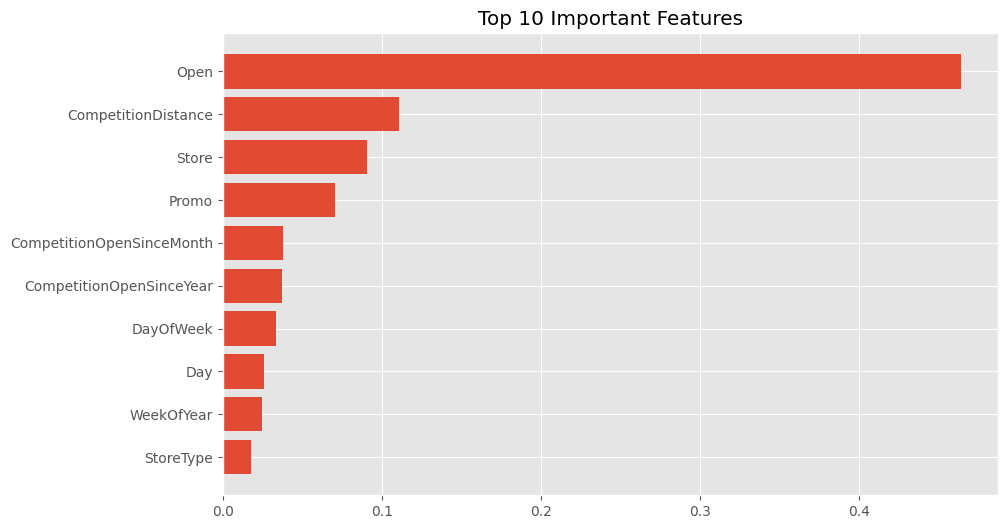

In [ ]:
import matplotlib.pyplot as plt

top_features = importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title('Top 10 Important Features')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
import joblib
from datetime import datetime

timestamp = datetime.now().strftime(
    "%d-%m-%Y-%H-%M-%S"
)

filename = f"rf_model_{timestamp}.pkl"

joblib.dump(rf, filename)

print(filename)

rf_model_31-05-2026-23-24-42.pkl


In [ ]:
import logging

logging.basicConfig(
    filename='rossmann.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logging.info("Dataset Loaded")
logging.info("Feature Engineering Completed")
logging.info("Random Forest Model Trained")

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                      Feature  Importance
2                        Open    0.464150
8         CompetitionDistance    0.110619
0                       Store    0.090345
3                       Promo    0.070281
9   CompetitionOpenSinceMonth    0.037775
10   CompetitionOpenSinceYear    0.037009
1                   DayOfWeek    0.033169
17                        Day    0.026059
18                 WeekOfYear    0.024330
6                   StoreType    0.017460


In [ ]:
import logging

logging.basicConfig(
    filename='rossmann.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logging.info("Dataset Loaded Successfully")
logging.info("EDA Completed")
logging.info("Feature Engineering Completed")
logging.info("Random Forest Model Trained")
logging.info("Model Saved Successfully")

In [ ]:
print(df.shape)

(1017209, 25)


In [ ]:
df[['Date','Sales']].head()

,Date,Sales
0,2015-07-31,5263
1,2015-07-31,6064
2,2015-07-31,8314
3,2015-07-31,13995
4,2015-07-31,4822


In [ ]:
store_1 = df[df['Store'] == 1]

store_1 = store_1.sort_values('Date')

store_1[['Date','Sales']].head()

,Date,Sales
1016095,2013-01-01,0
1014980,2013-01-02,5530
1013865,2013-01-03,4327
1012750,2013-01-04,4486
1011635,2013-01-05,4997


In [ ]:
ts = store_1[['Date','Sales']].copy()

ts.set_index('Date', inplace=True)

ts.head()

,Sales
Date,
2013-01-01,0
2013-01-02,5530
2013-01-03,4327
2013-01-04,4486
2013-01-05,4997


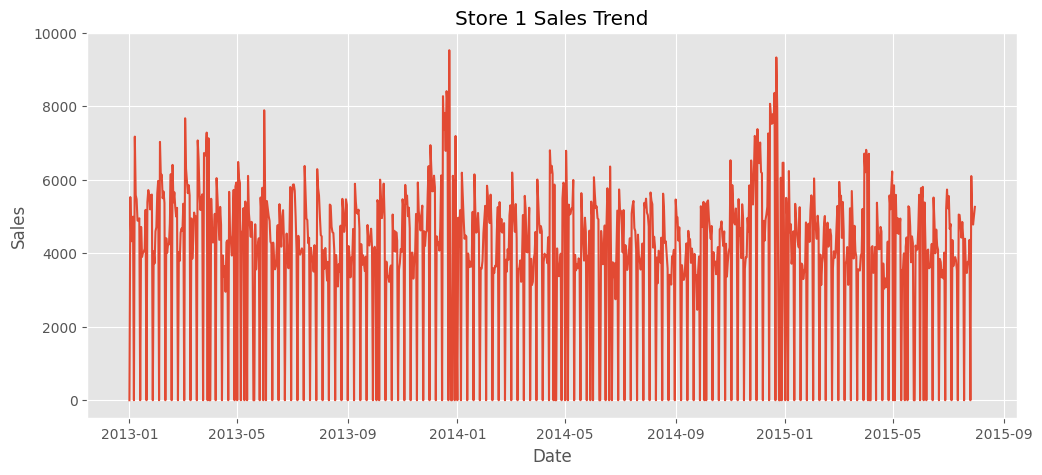

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(ts['Sales'])

plt.title("Store 1 Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [ ]:
pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 171.1 kB/s eta 0:00:53
   -- ------------------------------------- 0.5/9.5 MB 171.1 kB/s eta 0:00:53
   -- ------------------------------------- 0.5/9.5 MB 171.1 kB/s eta 0:00:53
   -- -


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts['Sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.368104368168501
p-value: 0.0003378834614142412


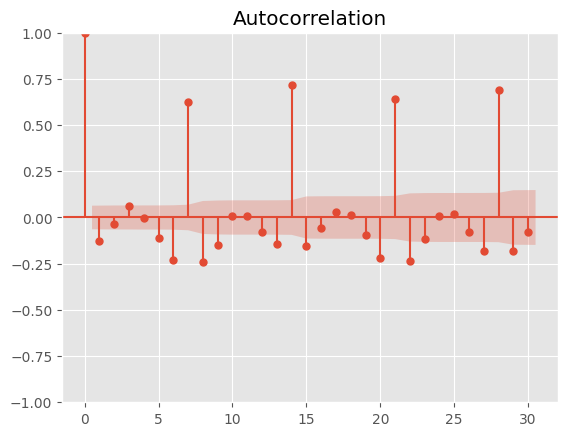

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(
    store_1['Sales'],
    lags=30
)

plt.show()

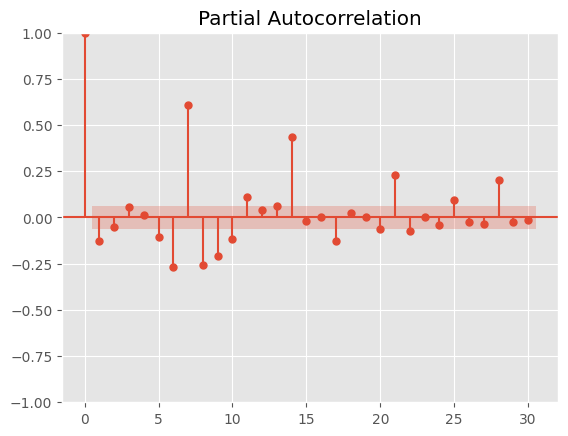

In [ ]:
plot_pacf(
    store_1['Sales'],
    lags=30
)

plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

sales = store_1['Sales'].values.reshape(-1,1)

scaler = MinMaxScaler(
    feature_range=(-1,1)
)

sales_scaled = scaler.fit_transform(sales)

In [ ]:
import numpy as np

def create_sequences(data, window_size=30):

    X = []
    y = []

    for i in range(
        len(data) - window_size
    ):
        X.append(
            data[i:i+window_size]
        )

        y.append(
            data[i+window_size]
        )

    return (
        np.array(X),
        np.array(y)
    )

X_lstm, y_lstm = create_sequences(
    sales_scaled,
    30
)

print(X_lstm.shape)
print(y_lstm.shape)

(912, 30, 1)
(912, 1)


In [ ]:
X_lstm = X_lstm.reshape(
    X_lstm.shape[0],
    X_lstm.shape[1],
    1
)

print(X_lstm.shape)

(912, 30, 1)


In [ ]:
split = int(
    len(X_lstm) * 0.8
)

X_train = X_lstm[:split]
X_test = X_lstm[split:]

y_train = y_lstm[:split]
y_test = y_lstm[split:]

In [ ]:
import tensorflow as tf

print(tf.__version__)

ModuleNotFoundError: No module named 'tensorflow'